# Implement PCA and Explore Corpus

## Setup

### Import Libraries

In [43]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA, TruncatedSVD as SVD

import plotly.express as px
import plotly.io as pio

sns.set_theme(style='white')
pio.renderers.default = 'vscode'

### Load Data

In [44]:
# load in tables
LIB = pd.read_csv('data/LIB.csv', sep='\t').set_index('book_id')
TFIDF_L2 = pd.read_csv('data/TFIDF_L2.csv', sep='\t').set_index(['book_id', 'chap_num']) # recall this is TFIDF_reduced L2 normalized

## Run PCA

Pass the TFIDF table with reduced feature space SKLearn's PCA class.

### Instantiate PCA Engine

I will start with default values for the constructor, and will set random_state to 36 and the number of components to 20. Then I will plot the cumulative explained variance, and then refit with my chosen number of components.

/tmp/ipykernel_968574/4086206609.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


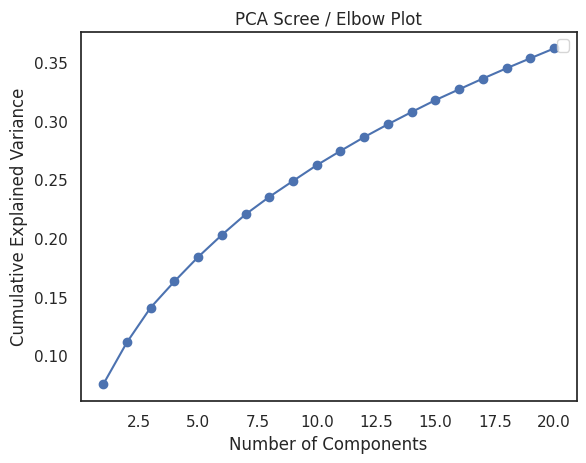

In [45]:
# instantiate PCA engine with defaults except random_state=36 and n_components=20
pca_explore = PCA(n_components=20, random_state=36)
pca_explore.fit(TFIDF_L2)

cumvar = np.cumsum(pca_explore.explained_variance_ratio_)

plt.plot(range(1, len(cumvar)+1), cumvar, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree / Elbow Plot')
plt.legend()
plt.show()

This scree plot doesn't have a pronounced elbow. Variance is accumulating slowly across components. I am choosing ten components as a practical limit to balance variance coverage and interpretability. 

In [46]:
# reinstantiate PCA engine with defaults except random_state=36 and n_components=10
pca_engine = PCA(n_components = 10, random_state = 36)

### Build PCA Document-Component Matrix (DCM)

Fit and transform the normalized, reduced TFIDF data (TFIDF_L2) to create the document component matrix.

In [47]:
# fit and transform the normalized reduced TFIDF data (pass it to PCA engine) to create document component matrix
DCM = pd.DataFrame(
    pca_engine.fit_transform(TFIDF_L2),
    index = TFIDF_L2.index # pca engine returns a numpy matrix which we turn back into a dataframe
)

DCM.columns = [f'PC{i}' for i in range(DCM.shape[1])]

# DCM # now we have a document component matrix

### Build PCA Loadings (Component-Term Matrix)

Create a data frame LOADINGS that contains terms as observations and components as features.

Here is the formula from our M07 HW: `pca_engine.components_.T * np.sqrt(pca_engine.explained_variance_)`

In [48]:
# create LOADINGS dataframe with terms as observations and components as features

LOADINGS = pd.DataFrame(
    pca_engine.components_.T * np.sqrt(pca_engine.explained_variance_),
    index = TFIDF_L2.columns,
    # use PC column names from DCM
    columns = DCM.columns
)

# confirm index name is 'term_str' (don't actually need bc this came through via BOW initially?)
LOADINGS.index.name = 'term_str'

# LOADINGS

### Create a DOC data frame for Visualization

I will now create a DOC table from the DCM index in which each row represents a bag (in this case chapter).

It will have ['book_id', 'chap_num'] as its index.

This table will have information from the LIB table joined to it, so that each chapter is identified with title, sleuth, original publication year, work type, and genre.

Finally, I will add a DOC feature label that is a string which concatenates book_id and chapter.

These data will appear in my visualizations.

In [49]:
# create initial DOC table with DCM index
DOC = pd.DataFrame(index=DCM.index)

# join metadata from LIB (join on book_id)
DOC = DOC.join(LIB[['title', 'sleuth', 'pub_year_original', 'work_type', 'genre']], on='book_id')

# create label column
book_str = DOC.index.get_level_values('book_id')
chap_str = DOC.index.get_level_values('chap_num').astype(str)

DOC['label'] = book_str + ' ch.' + chap_str

In [50]:
# extract primary genre
DOC['primary_genre'] = DOC['genre'].str.split('|').str[0]

# DOC

## Visualize

### PCA Visualization 1

#### Scatterplot of documents in the space created by the first two components

With points colored by metadata features.

In [51]:
# create a scatterplot of documents in the space created by the first 2 components
# coloring the points by sleuth

# fill the NaN for works without a sleuth (Giant's Bread)
DOC['sleuth'] = DOC['sleuth'].fillna('None')

px.scatter(
    data_frame = DCM.join(DOC).reset_index(),
    x = 'PC0', # first PC
    y = 'PC1', # second PC
    color = 'sleuth', # color by sleuth
    hover_name = 'label', # use concat string for hover info
    hover_data=['pub_year_original', 'work_type', 'primary_genre'], # add more hover data
    marginal_x = 'box' # add boxplot to x axis
)

#### Scatterplot of the loadings for the first two components

In [52]:
px.scatter(
    data_frame = LOADINGS.reset_index(),
    x = 'PC0', # first PC
    y = 'PC1', # second PC
    hover_name = 'term_str',
    marginal_x = 'box'
)

In [53]:
print(LOADINGS['PC0'].sort_values().head(10))  # most negative
print(LOADINGS['PC0'].sort_values().tail(10))  # most positive

term_str
monsieur       -0.019026
hastings       -0.017284
madame         -0.017035
colonel        -0.016335
inspector      -0.015167
mademoiselle   -0.013345
train          -0.011194
friend         -0.011174
dr             -0.011143
mother         -0.010769
Name: PC0, dtype: float64
term_str
party        0.003447
dangerous    0.003491
terrace      0.003497
foreign      0.005149
seven        0.011869
lady         0.015305
george       0.027573
lord         0.047462
bill         0.070832
bundle       0.199422
Name: PC0, dtype: float64


In [54]:
print(LOADINGS['PC1'].sort_values().head(10))  # most negative
print(LOADINGS['PC1'].sort_values().tail(10))  # most positive

term_str
colonel     -0.059154
inspector   -0.022377
want        -0.018255
really      -0.016683
ca          -0.016108
dear        -0.015067
mother      -0.012507
love        -0.012172
people      -0.012070
kind        -0.011219
Name: PC1, dtype: float64
term_str
paris           0.015285
de              0.015903
hercule         0.016162
ami             0.018645
train           0.019939
mon             0.021576
hastings        0.031354
mademoiselle    0.037740
monsieur        0.064222
madame          0.064379
Name: PC1, dtype: float64


In [55]:
# how much do the first 4 components contribute to variation
pca_engine.explained_variance_ratio_[:4]

array([0.07531743, 0.03590291, 0.02964887, 0.02226467])

This corpus doesn't have one major axis of variation. The variance is spread thinly over many dimensions which suggests that the books are more alike than not at the lexical level. This makes sense given a corpus from a single author working in a consistent genre. 

PC0 explains only 7.5% of variance. PC1 explains only 3.6% of variance. This is consistent with a stylistically uniform single-author corpus in which no single lexical dimension is dominant.

#### Brief description of the nature of the polarity seen in the first component

The negative pole of PC0 is comprised of French terms of address (monsieur, madame, mademoiselle), Hastings, and procedural roles. This end of PC0 is a distributed signal of Poirot's register.

The positive pole is dominated by the term "bundle" (loading ~ 0.20), a character name referring to Lady Eileen "Bundle" Brent in The Secret of Chimneys and The Seven Dials Mystery.

This asymmetry of one outlier term vs a distributed pole suggests that PC0 is partly a book-identity axis rather than a pure register one.

### PCA Visualization 2

#### Scatterplot of documents in the space created by the second two components

With points colored by metadata features.

Sleuth did not provide great interpretibility here but primary genre worked well.

In [56]:
# create a scatterplot of documents in the space created by the second 2 components
# coloring the points by primary_genre

px.scatter(
    data_frame = DCM.join(DOC).reset_index(),
    x = 'PC2', # third PC
    y = 'PC3', # fourth PC
    color = 'primary_genre', # color by primary_genre
    hover_name = 'label', # use concat string for hover info
    hover_data=['sleuth', 'pub_year_original', 'work_type'], # add more hover data
    marginal_x = 'box' # add boxplot to x axis
)

#### Scatterplot of the loadings for the second two components

In [57]:
px.scatter(
    data_frame = LOADINGS.reset_index(),
    x = 'PC2', # third PC
    y = 'PC3', # fourth PC
    hover_name = 'term_str',
    marginal_x = 'box'
)

In [58]:
print(LOADINGS['PC2'].sort_values().head(10))  # most negative
print(LOADINGS['PC2'].sort_values().tail(10))  # most positive

term_str
mother   -0.030730
father   -0.024539
love     -0.023498
george   -0.021315
green    -0.015952
boy      -0.015819
girl     -0.015502
marry    -0.015435
child    -0.012967
happy    -0.012864
Name: PC2, dtype: float64
term_str
village      0.011251
shot         0.011695
telephone    0.011864
bundle       0.012109
clock        0.013805
police       0.014249
murder       0.015187
dr           0.019224
colonel      0.057145
inspector    0.076961
Name: PC2, dtype: float64


In [59]:
print(LOADINGS['PC3'].sort_values().head(10))  # most negative
print(LOADINGS['PC3'].sort_values().tail(10))  # most positive

term_str
hastings   -0.037126
lord       -0.028563
four       -0.025574
number     -0.019740
george     -0.019729
big        -0.017975
friend     -0.016893
doctor     -0.015607
house      -0.014247
ami        -0.011054
Name: PC3, dtype: float64
term_str
paris           0.011023
mother          0.011198
madame          0.014338
lady            0.014488
father          0.014883
de              0.017244
train           0.026942
monsieur        0.033041
colonel         0.041495
mademoiselle    0.041826
Name: PC3, dtype: float64


#### Brief description of the nature of the polarity seen in the third (?) component

The negative pole of PC2 is comprised of terms related to family, romance, and domestic life (mother, father, love, child, marry). 

The positive pole is comprised of terms belonging to the apparatus of detection (village, police, murder, inspector, colonel, 
clock).

This suggests that PC2 may represent an axis of domestic interior life vs. procedural investigation - a tension that runs through Christie's genre conventions regardless of which detective is present.

## Save Outputs

In [60]:
# save the DCM table to csv
DCM.to_csv('data/PCA_DCM.csv', sep='\t', index=True)

# save the LOADINGS table to csv
LOADINGS.to_csv('data/PCA_LOADINGS.csv', sep='\t', index=True)

# save the DOC table to csv
DOC.to_csv('data/PCA_DOC.csv', sep='\t', index=True)